In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Data Preprocessing

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/Datasets/creditcard.csv'
data = pd.read_csv(drive_path)

Mounted at /content/drive


In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data.shape

(284807, 31)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
data.drop_duplicates(inplace= True)

In [7]:
data.Time.mean()

np.float64(94811.07759951502)

In [8]:
X = data.drop(columns=['Class'], axis= 1)
y = data['Class']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train, val_X_train, y_train, val_y_train = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [11]:
scale = StandardScaler()
X_train[['Time', 'Amount']] = scale.fit_transform(X_train[['Time', 'Amount']])
val_X_train[['Time', 'Amount']] = scale.transform(val_X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scale.transform(X_test[['Time', 'Amount']])

# Imbalanced Data Handling

In [12]:
y_train.value_counts()

,count
Class,
0,181275
1,309


In [13]:
smote = SMOTE(sampling_strategy= 'minority', random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [14]:
X_train.shape

(362550, 30)

# ANN Model:

In [21]:
def create_model(X_train, y_train, val_X_train, val_y_train, layer_1_neurons, layer_2_neurons, layer_3_neurons, activation, optimizer, epochs, batch_size):
  model = Sequential([Dense(layer_1_neurons, activation=activation, input_shape=(X_train.shape[1],)),
                      Dense(layer_2_neurons, activation=activation),
                      Dense(layer_3_neurons, activation=activation),
                      Dense(1, activation='sigmoid')])
  model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
  history = model.fit(X_train, y_train, epochs = epochs, batch_size = batch_size, validation_data = (val_X_train, val_y_train))

  pred_y_train = model.predict(X_train)
  pred_val_y_train = model.predict(val_X_train)
  print('-----> Train Data Report <-----')
  print(classification_report(y_train, (pred_y_train > 0.5).astype('int')))
  print('-----> Validataion Data Report <-----')
  print(classification_report(val_y_train, (pred_val_y_train > 0.5).astype('int')))
  print('-----> Train Data Confusion Matrix <-----')
  print(confusion_matrix(y_train, (pred_y_train > 0.5).astype('int')))
  print('-----> Validataion Data Confusion Matrix <-----')
  print(confusion_matrix(val_y_train, (pred_val_y_train > 0.5).astype('int')))
  return model, history

# 3 Different Activation Configurations

In [24]:
# relu activation function using
model_1, history_1 = create_model(X_train, y_train,
                       val_X_train, val_y_train,
                       32, 16, 8,
                       'relu', 'adam',
                       10, 250)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9783 - loss: 0.0575 - val_accuracy: 0.9956 - val_loss: 0.0192
Epoch 2/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9985 - loss: 0.0072 - val_accuracy: 0.9978 - val_loss: 0.0139
Epoch 3/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accuracy: 0.9985 - val_loss: 0.0141
Epoch 4/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9976 - val_loss: 0.0181
Epoch 5/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9989 - val_loss: 0.0141
Epoch 6/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9988 - val_loss: 0.0163
Epoch 7/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9987 - val_loss: 0.0161
Epoch 8/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9995 - loss: 0.0023 

In [25]:
# tanh activation function using
model_2, history_2 = create_model(X_train, y_train,
                       val_X_train, val_y_train,
                       32, 16, 8,
                       'tanh', 'adam',
                       10, 250)

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9720 - loss: 0.0814 - val_accuracy: 0.9898 - val_loss: 0.0308
Epoch 2/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9953 - loss: 0.0161 - val_accuracy: 0.9944 - val_loss: 0.0177
Epoch 3/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9974 - loss: 0.0097 - val_accuracy: 0.9954 - val_loss: 0.0166
Epoch 4/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9981 - loss: 0.0074 - val_accuracy: 0.9973 - val_loss: 0.0122
Epoch 5/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9985 - loss: 0.0062 - val_accuracy: 0.9972 - val_loss: 0.0114
Epoch 6/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9979 - val_loss: 0.0097
Epoch 7/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9991 - loss: 0.0044 - val_accuracy: 0.9980 - val_loss: 0.0101
Epoch 8/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9991 - loss: 0.0041 - val_accurac

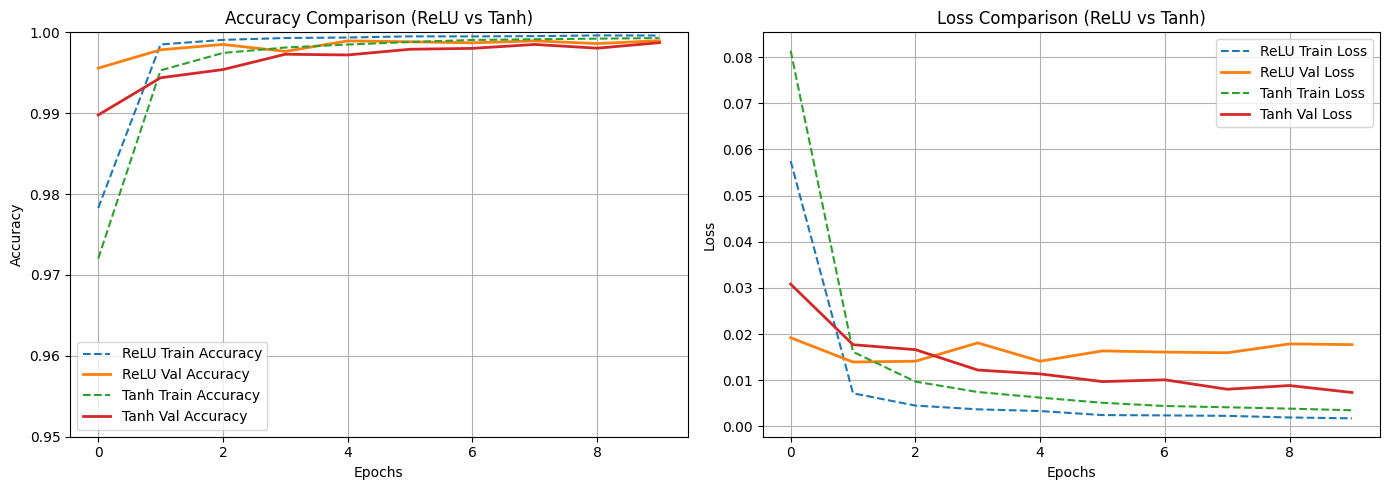

In [36]:
plt.figure(figsize=(14, 5))

# 1. Training & Validation Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='ReLU Train Accuracy', linestyle='--')
plt.plot(history_1.history['val_accuracy'], label='ReLU Val Accuracy', linewidth=2)
plt.plot(history_2.history['accuracy'], label='Tanh Train Accuracy', linestyle='--')
plt.plot(history_2.history['val_accuracy'], label='Tanh Val Accuracy', linewidth=2)
plt.title('Accuracy Comparison (ReLU vs Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1.0) # Scale zoom karne ke liye taake farq saaf nazar aaye
plt.legend()
plt.grid(True)

# 2. Training & Validation Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='ReLU Train Loss', linestyle='--')
plt.plot(history_1.history['val_loss'], label='ReLU Val Loss', linewidth=2)
plt.plot(history_2.history['loss'], label='Tanh Train Loss', linestyle='--')
plt.plot(history_2.history['val_loss'], label='Tanh Val Loss', linewidth=2)
plt.title('Loss Comparison (ReLU vs Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We selected ReLU because it achieved higher precision and produced fewer false positives (36 vs 49) on the validation set compared to Tanh, making it more practical for real-world fraud detection.

# 3 Different Optimizer Configurations

In [33]:
# adam optimizer has already use with relu activation


pred_y_train_adam = model_1.predict(X_train)
pred_val_y_train_adam = model_1.predict(val_X_train)
print('-----> Train Data Report <-----')
print(classification_report(y_train, (pred_y_train_adam > 0.5).astype('int')))
print('-----> Validataion Data Report <-----')
print(classification_report(val_y_train, (pred_val_y_train_adam > 0.5).astype('int')))
print('-----> Train Data Confusion Matrix <-----')
print(confusion_matrix(y_train, (pred_y_train_adam > 0.5).astype('int')))
print('-----> Validataion Data Confusion Matrix <-----')
print(confusion_matrix(val_y_train, (pred_val_y_train_adam > 0.5).astype('int')))

11330/11330 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
-----> Train Data Report <-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    181275
           1       1.00      1.00      1.00    181275

    accuracy                           1.00    362550
   macro avg       1.00      1.00      1.00    362550
weighted avg       1.00      1.00      1.00    362550

-----> Validataion Data Report <-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45322
           1       0.64      0.85      0.73        74

    accuracy                           1.00     45396
   macro avg       0.82      0.93      0.86     45396
weighted avg       1.00      1.00      1.00     45396

-----> Train Data Confusion Matrix <-----
[[181194     81]
 [     0 181275]]
-----> Validataion Data Confusion Matrix <-----
[[45286    36]
 [   11    63]]


In [34]:
# SGD optamizer using
model_3, history_3 = create_model(X_train, y_train,
                       val_X_train, val_y_train,
                       32, 16, 8,
                       'relu', 'SGD',
                       10, 250)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9286 - loss: 0.1870 - val_accuracy: 0.9774 - val_loss: 0.1006
Epoch 2/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9555 - loss: 0.1062 - val_accuracy: 0.9766 - val_loss: 0.0824
Epoch 3/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9678 - loss: 0.0819 - val_accuracy: 0.9777 - val_loss: 0.0688
Epoch 4/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9774 - loss: 0.0630 - val_accuracy: 0.9804 - val_loss: 0.0587
Epoch 5/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9830 - loss: 0.0488 - val_accuracy: 0.9821 - val_loss: 0.0519
Epoch 6/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9877 - loss: 0.0394 - val_accuracy: 0.9852 - val_loss: 0.0446
Epoch 7/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0332 - val_accuracy: 0.9851 - val_loss: 0.0434
Epoch 8/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9924 - loss: 0.0285 -

In [35]:
# RMSprop optamizer using
model_4, history_4 = create_model(X_train, y_train,
                       val_X_train, val_y_train,
                       32, 16, 8,
                       'relu', 'RMSprop',
                       10, 250)

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9933 - val_loss: 0.0251
Epoch 2/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9984 - loss: 0.0076 - val_accuracy: 0.9971 - val_loss: 0.0163
Epoch 3/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9990 - loss: 0.0049 - val_accuracy: 0.9981 - val_loss: 0.0161
Epoch 4/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9978 - val_loss: 0.0182
Epoch 5/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.9986 - val_loss: 0.0174
Epoch 6/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9985 - val_loss: 0.0191
Epoch 7/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9984 - val_loss: 0.0207
Epoch 8/10
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accurac

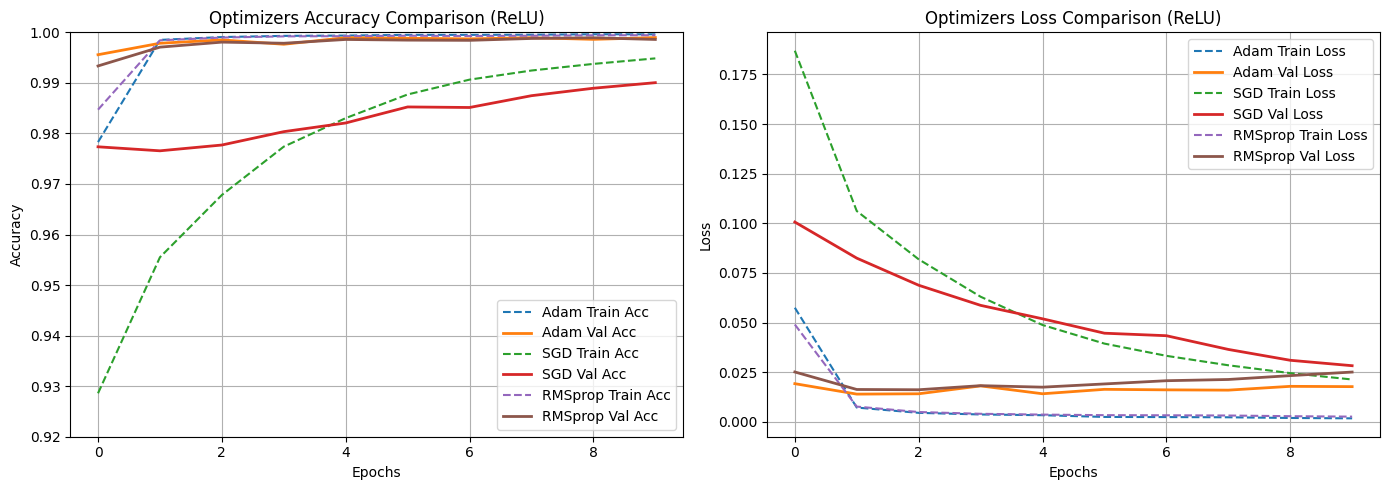

In [37]:
plt.figure(figsize=(14, 5))

# 1. Accuracy Plot (Train vs Val for Adam, SGD, RMSprop)
plt.subplot(1, 2, 1)
# Adam (history_1)
plt.plot(history_1.history['accuracy'], label='Adam Train Acc', linestyle='--')
plt.plot(history_1.history['val_accuracy'], label='Adam Val Acc', linewidth=2)

# SGD (history_3)
plt.plot(history_3.history['accuracy'], label='SGD Train Acc', linestyle='--')
plt.plot(history_3.history['val_accuracy'], label='SGD Val Acc', linewidth=2)

# RMSprop (history_4)
plt.plot(history_4.history['accuracy'], label='RMSprop Train Acc', linestyle='--')
plt.plot(history_4.history['val_accuracy'], label='RMSprop Val Acc', linewidth=2)

plt.title('Optimizers Accuracy Comparison (ReLU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.92, 1.0)  # Farq saaf dekhne ke liye zoom scale
plt.legend()
plt.grid(True)

# 2. Loss Plot (Train vs Val for Adam, SGD, RMSprop)
plt.subplot(1, 2, 2)
# Adam
plt.plot(history_1.history['loss'], label='Adam Train Loss', linestyle='--')
plt.plot(history_1.history['val_loss'], label='Adam Val Loss', linewidth=2)

# SGD
plt.plot(history_3.history['loss'], label='SGD Train Loss', linestyle='--')
plt.plot(history_3.history['val_loss'], label='SGD Val Loss', linewidth=2)

# RMSprop
plt.plot(history_4.history['loss'], label='RMSprop Train Loss', linestyle='--')
plt.plot(history_4.history['val_loss'], label='RMSprop Val Loss', linewidth=2)

plt.title('Optimizers Loss Comparison (ReLU)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We selected Adam as the best optimizer because it achieved the fastest convergence, the highest precision (0.64), and the lowest number of false positives (36) on the validation set compared to SGD and RMSprop.

# Model Training On Different Epochs

In [38]:
# model training on 5 epochs
model_5, history_5 = create_model(X_train, y_train,
                       val_X_train, val_y_train,
                       32, 16, 8,
                       'relu', 'adam',
                       5, 250)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9741 - loss: 0.0658 - val_accuracy: 0.9948 - val_loss: 0.0233
Epoch 2/5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9980 - loss: 0.0098 - val_accuracy: 0.9975 - val_loss: 0.0126
Epoch 3/5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9989 - loss: 0.0055 - val_accuracy: 0.9981 - val_loss: 0.0144
Epoch 4/5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9985 - val_loss: 0.0146
Epoch 5/5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9994 - loss: 0.0037 - val_accuracy: 0.9986 - val_loss: 0.0147
11330/11330 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
-----> Train Data Report <-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    181275
           1       1.00      1.00      1.00    181275

    accuracy                           1.00    362550
   macro avg  

In [39]:
# model training on 20 epochs
model_6, history_6 = create_model(X_train, y_train,
                       val_X_train, val_y_train,
                       32, 16, 8,
                       'relu', 'adam',
                       20, 250)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9825 - loss: 0.0518 - val_accuracy: 0.9945 - val_loss: 0.0204
Epoch 2/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9983 - loss: 0.0080 - val_accuracy: 0.9974 - val_loss: 0.0166
Epoch 3/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9991 - loss: 0.0047 - val_accuracy: 0.9976 - val_loss: 0.0182
Epoch 4/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9985 - val_loss: 0.0177
Epoch 5/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9987 - val_loss: 0.0182
Epoch 6/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9995 - loss: 0.0027 - val_accuracy: 0.9989 - val_loss: 0.0192
Epoch 7/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9990 - val_loss: 0.0192
Epoch 8/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9996 - loss: 0.0020 -

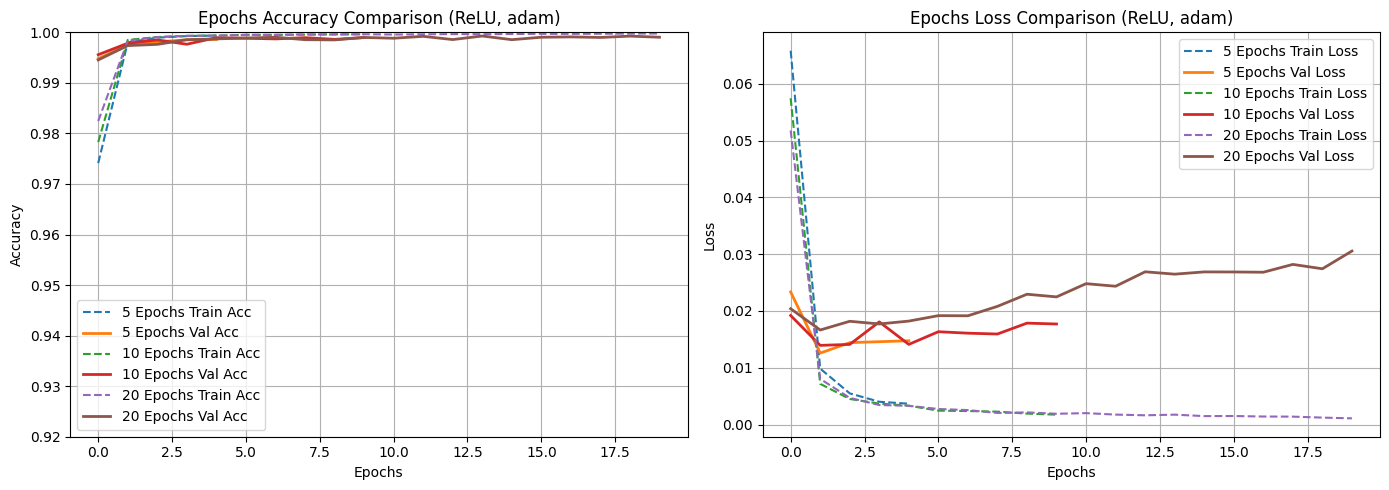

In [40]:
plt.figure(figsize=(14, 5))

# 1. Accuracy Plot (Train vs Val for 5, 10, 20 epochs)
plt.subplot(1, 2, 1)
# 5 (history_5)
plt.plot(history_5.history['accuracy'], label='5 Epochs Train Acc', linestyle='--')
plt.plot(history_5.history['val_accuracy'], label='5 Epochs Val Acc', linewidth=2)

# 10 (history_1)
plt.plot(history_1.history['accuracy'], label='10 Epochs Train Acc', linestyle='--')
plt.plot(history_1.history['val_accuracy'], label='10 Epochs Val Acc', linewidth=2)

# 20 (history_6)
plt.plot(history_6.history['accuracy'], label='20 Epochs Train Acc', linestyle='--')
plt.plot(history_6.history['val_accuracy'], label='20 Epochs Val Acc', linewidth=2)

plt.title('Epochs Accuracy Comparison (ReLU, adam)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.92, 1.0)  # Farq saaf dekhne ke liye zoom scale
plt.legend()
plt.grid(True)

# 2. Loss Plot (Train vs Val for 5, 10, 20 epochs)
plt.subplot(1, 2, 2)
# 5 (history_5)
plt.plot(history_5.history['loss'], label='5 Epochs Train Loss', linestyle='--')
plt.plot(history_5.history['val_loss'], label='5 Epochs Val Loss', linewidth=2)

# 10 (history_1)
plt.plot(history_1.history['loss'], label='10 Epochs Train Loss', linestyle='--')
plt.plot(history_1.history['val_loss'], label='10 Epochs Val Loss', linewidth=2)

# 20 (history_6)
plt.plot(history_6.history['loss'], label='20 Epochs Train Loss', linestyle='--')
plt.plot(history_6.history['val_loss'], label='20 Epochs Val Loss', linewidth=2)

plt.title('Epochs Loss Comparison (ReLU, adam)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We selected 10 Epochs as optimal because 5 epochs were slightly underfitted, while 20 epochs caused overfitting as indicated by the rising validation loss after epoch 5.

# Evaluation

In [45]:
test_loss, test_accuracy = model_1.evaluate(X_test, y_test)

print("=========================================================")
print("-------------> FINAL EVALUATION COMPARISON <-------------")
print("=========================================================")
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy * 100:.2f}%')

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9991 - loss: 0.0206
-------------> FINAL EVALUATION COMPARISON <-------------
Test Loss : 0.0206
Test Accuracy : 99.91%


# Prediction

In [46]:
y_pred_test = model_1.predict(X_test)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [56]:
test_compare = pd.DataFrame({'Actual': y_test.values, 'Predict': (y_pred_test > 0.5).astype('int').flatten()})
test_compare.head()

,Actual,Predict
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


-----> FINAL TEST DATA CLASSIFICATION REPORT <-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.67      0.80      0.73        90

    accuracy                           1.00     56746
   macro avg       0.84      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746



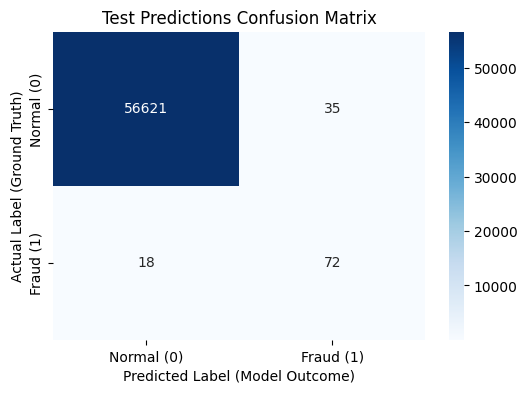

In [57]:
# 1. Detailed Classification Report (Precision, Recall, F1-Score)
print("-----> FINAL TEST DATA CLASSIFICATION REPORT <-----")
print(classification_report(y_test, (y_pred_test > 0.5).astype('int')))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, (y_pred_test > 0.5).astype('int'))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title('Test Predictions Confusion Matrix')
plt.xlabel('Predicted Label (Model Outcome)')
plt.ylabel('Actual Label (Ground Truth)')
plt.show()

# Model Comparison

In [61]:
models = [model_1, model_2, model_3, model_4, model_5, model_6]
precisions, recalls, false_positive = [], [], []
for m in models:
  val_pred = (m.predict(val_X_train) > 0.5).astype('int')

  precisions.append(round(precision_score(val_y_train, val_pred, pos_label=1), 2))
  recalls.append(round(recall_score(val_y_train, val_pred, pos_label=1), 2))

  tn, fp, fn, tp = confusion_matrix(val_y_train, val_pred).ravel()
  false_positive.append(fp)

1419/1419 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [64]:
pd.DataFrame({'Model': ['model_1', 'model_2', 'model_3', 'model_4', 'model_5', 'model_6'],
              'Activation': ['ReLU', 'Tanh', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],
              'Optimizer': ['adam', 'adam', 'SGD', 'RMSprop', 'adam', 'adam'],
              'Epochs': [10, 10, 10, 10, 5, 20],
              'Val Accuracy (%)': [round(history_1.history['val_accuracy'][-1] * 100, 2),
                                   round(history_2.history['val_accuracy'][-1] * 100, 2),
                                   round(history_3.history['val_accuracy'][-1] * 100, 2),
                                   round(history_4.history['val_accuracy'][-1] * 100, 2),
                                   round(history_5.history['val_accuracy'][-1] * 100, 2),
                                   round(history_6.history['val_accuracy'][-1] * 100, 2)],
              'Precision': precisions,
              'Recall': recalls,
              'False Positive': false_positive
              })

,Model,Activation,Optimizer,Epochs,Val Accuracy (%),Precision,Recall,False Positive
0,model_1,ReLU,adam,10,99.90,0.64,0.85,36
1,model_2,Tanh,adam,10,99.87,0.57,0.88,49
2,model_3,ReLU,SGD,10,99.00,0.13,0.88,443
3,model_4,ReLU,RMSprop,10,99.86,0.54,0.82,51
4,model_5,ReLU,adam,5,99.86,0.54,0.91,57
5,model_6,ReLU,adam,20,99.90,0.65,0.88,35


# Best Model Selection:
model_1 (ReLU Activation, Adam Optimizer, 10 Epochs) is selected as the optimal model. It achieves the highest precision (0.64) with only 36 False Positives on the validation set, while maintaining a strong 0.85 Recall for fraud detection without overfitting.